In [ ]:
from transformers import SamModel, SamProcessor
import torch 

model = SamModel.from_pretrained("facebook/sam-vit-base")
processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("SAM loaded!")

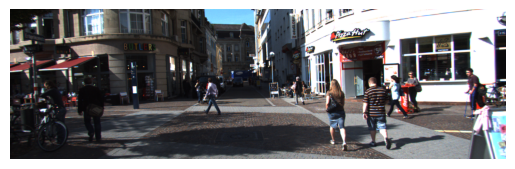

In [13]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week2/data/kitti-mots/train/img/0019_000576.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

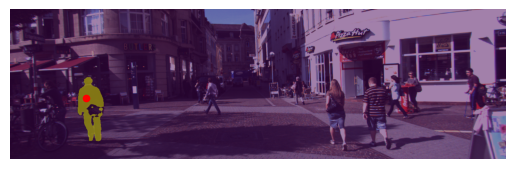

In [25]:
input_points = [[[190, 220]]]  
input_labels = [[1]]          

inputs = processor(
    image,
    input_points=input_points,
    input_labels=input_labels,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)

mask = masks[0][0][0].numpy()

import matplotlib.pyplot as plt


plt.imshow(image)

x, y = input_points[0][0]
plt.scatter(x, y, c="red", s=20, marker="o")

plt.imshow(mask, alpha=0.5)
plt.axis("off")
plt.show()

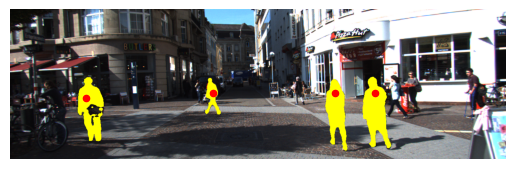

In [43]:
import numpy as np
import matplotlib.pyplot as plt

points = [[505,210], [810,210], [910,210], [190,220]]

result = image.copy()

colors = [
    [255,0,0],   # red
    [0,255,0],   # green
    [0,0,255],   # blue
    [255,255,0]  # yellow
]

for i, point in enumerate(points):

    inputs = processor(
        image,
        input_points=[[[point[0], point[1]]]],
        input_labels=[[1]],
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    masks = processor.image_processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"].cpu(),
        inputs["reshaped_input_sizes"].cpu()
    )

    mask = masks[0][0][0].numpy().astype(bool)

    # draw mask only where mask == True
    result[mask] = [255,255,0] 

plt.imshow(result)

for point in points:
    plt.scatter(point[0], point[1], c="RED", s=20)

plt.axis("off")
plt.show()

In [2]:
import sys
sys.path.append("/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week2/src")
from utils.kitti_dataset import KittiDataset

dataset = KittiDataset(
    "/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week2/data/KITTI-MOTS/training/image_02",
    "/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week2/data/KITTI-MOTS/instances_txt"
)

print(f"Dataset size: {len(dataset)} samples")

sample = dataset[0] 

print(sample["image"].shape)
print(sample["masks"].shape)
print(sample["class_ids"].shape)

Dataset size: 8008 samples
torch.Size([3, 375, 1242])
torch.Size([1, 375, 1242])
torch.Size([1])


Class IDs in the sample: [1 1 1 1 1]


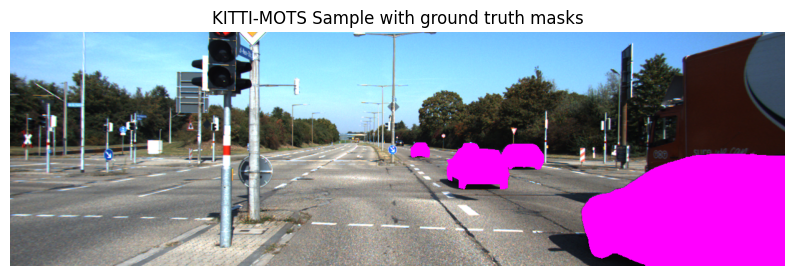

In [3]:
import numpy as np
import matplotlib.pyplot as plt

sample = dataset[1662]

image = sample["image"].permute(1,2,0).numpy().astype(np.uint8)
masks = sample["masks"].numpy()
class_ids = sample["class_ids"].numpy().astype(int)

result = image.copy()

colors = [
    [255,0,0],   # red
    [0,255,0],   # green
    [0,0,255],   # blue
    [255,255,0], # yellow
    [255,0,255]  # magenta
]

for i, mask in enumerate(masks):

    mask = mask.astype(bool)

    color = colors[4]

    # apply color only where mask is True
    result[mask] = color

print(f"Class IDs in the sample: {class_ids}")

plt.figure(figsize=(10,5))
plt.title("KITTI-MOTS Sample with ground truth masks")
plt.imshow(result)
plt.axis("off")
plt.show()

In [4]:
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2

def compute_iou(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    intersection = (pred & gt).sum()
    union = (pred | gt).sum()

    if union == 0:
        return 0

    return intersection / union

def random_point_from_mask(mask):

    ys, xs = np.where(mask)

    idx = np.random.randint(len(xs))

    return [xs[idx], ys[idx]]

def point_from_mask_center(mask):

    ys, xs = np.where(mask)

    cx = int(xs.mean())
    cy = int(ys.mean())

    return [cx, cy]

def interior_point_from_mask(mask):

    mask = mask.astype(np.uint8)

    # distance to nearest background pixel
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)

    # location of maximum distance (most interior pixel)
    y, x = np.unravel_index(dist.argmax(), dist.shape)

    return [x, y]

ious = []
car_ious = []
pedestrian_ious = []

for i in tqdm(range(len(dataset))):

    sample = dataset[i]

    image = sample["image"].permute(1,2,0).numpy().astype(np.uint8)
    masks = sample["masks"].numpy()
    class_ids = sample["class_ids"].numpy().astype(int)

    if len(masks) == 0:
        continue

    for gt_mask in masks:

        # random point inside GT mask
        point = interior_point_from_mask(gt_mask)

        inputs = processor(
            image,
            input_points=[[[point[0], point[1]]]],
            input_labels=[[1]],
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        pred_masks = processor.image_processor.post_process_masks(
            outputs.pred_masks.cpu(),
            inputs["original_sizes"].cpu(),
            inputs["reshaped_input_sizes"].cpu()
        )

        pred_mask = pred_masks[0][0][0].numpy()

        if pred_mask.shape != gt_mask.shape:
            pred_mask = cv2.resize(
                pred_mask.astype(np.uint8),
                (gt_mask.shape[1], gt_mask.shape[0]),
                interpolation=cv2.INTER_NEAREST
            )

        iou = compute_iou(pred_mask, gt_mask)

        """
        print(f"Low IoU ({iou:.4f}) for sample {i}")    

        plt.imshow(image)
        plt.imshow(pred_mask, alpha=0.8)
        plt.scatter(point[0], point[1], c="red", s=20) 
        plt.title(f"Sample {i} - IoU: {iou:.4f}")
        plt.axis("off")
        plt.show()

        plt.imshow(image)
        plt.imshow(gt_mask, alpha=0.8
                    )
        plt.title(f"Sample {i} - Ground Truth Mask")
        plt.axis("off")

        plt.show()

        """
        ious.append(iou)

        if class_ids[0] == 1:  
            car_ious.append(iou)

        elif class_ids[0] == 2:  
            pedestrian_ious.append(iou)

  0%|          | 0/8008 [00:00<?, ?it/s]

100%|██████████| 8008/8008 [1:12:39<00:00,  1.84it/s]


In [5]:
mean_iou = np.mean(ious)

print(f"Mean IoU for cars: {np.mean(car_ious):.4f} over {len(car_ious)} samples")
print(f"Mean IoU for pedestrians: {np.mean(pedestrian_ious):.4f} over {len(pedestrian_ious)} samples")

print("Mean IoU:", mean_iou)    
print("Num objects evaluated:", len(ious))

Mean IoU for cars: 0.7574 over 35462 samples
Mean IoU for pedestrians: 0.7390 over 2813 samples
Mean IoU: 0.7560261727433437
Num objects evaluated: 38275
